In [1]:
# run this to see all the outputs below each cell, not only the last instruction
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


# extract class names from XML labels

In [2]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

# change this to the directory containing your XML files
XML_DIR = "/media/nima/7CEEFEC0EEFE71AE/space/M3FD/Annotation/"

class_counter = Counter()

for root_dir, _, files in os.walk(XML_DIR):
    for file in files:
        if file.endswith(".xml"):
            xml_path = os.path.join(root_dir, file)
            try:
                tree = ET.parse(xml_path)
                root = tree.getroot()

                # Pascal VOC: each object has a <name> tag
                for obj in root.findall("object"):
                    class_name = obj.find("name").text.strip()
                    class_counter[class_name] += 1

            except Exception as e:
                print(f"[ERROR] Failed to parse {xml_path}: {e}")

# print results
print("Classes found:\n")
for cls, count in class_counter.items():
    print(f"{cls}: {count}")

print("\nTotal unique classes:", len(class_counter))


Classes found:

People: 11477
Car: 18296
Lamp: 2405
Bus: 700
Motorcycle: 521
Truck: 1008

Total unique classes: 6


# convert .xml to YOLO .txt label

In [3]:
import os
import xml.etree.ElementTree as ET

# Paths
XML_DIR = "/media/nima/7CEEFEC0EEFE71AE/space/M3FD/Annotation/"          # folder containing XML files
TXT_DIR = "/media/nima/7CEEFEC0EEFE71AE/space/M3FD/Annotation/"      # output folder for YOLO txt files

os.makedirs(TXT_DIR, exist_ok=True)

# Class mapping (EDIT THIS to match your dataset)
CLASS_MAPPING = {
    "People": 0,
    "Car": 1,
    "Bus": 2,
    "Motorcycle": 3,
    "Lamp": 4,
    "Truck": 5,
    # add more classes here
}

IMG_WIDTH = 1024
IMG_HEIGHT = 768


def convert_xml_to_yolo(xml_path, txt_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_MAPPING:
            continue  # skip unknown classes

        class_id = CLASS_MAPPING[class_name]

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        # Convert to YOLO format (normalized)
        x_center = ((xmin + xmax) / 2) / IMG_WIDTH
        y_center = ((ymin + ymax) / 2) / IMG_HEIGHT
        width = (xmax - xmin) / IMG_WIDTH
        height = (ymax - ymin) / IMG_HEIGHT

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    with open(txt_path, "w") as f:
        f.write("\n".join(yolo_lines))


# Iterate over all XML files
for xml_file in os.listdir(XML_DIR):
    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(XML_DIR, xml_file)
    txt_file = xml_file.replace(".xml", ".txt")
    txt_path = os.path.join(TXT_DIR, txt_file)

    convert_xml_to_yolo(xml_path, txt_path)

print("✅ XML → YOLO TXT conversion completed.")


✅ XML → YOLO TXT conversion completed.


# plot an image with txt label

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(768, 1024, 3), dtype=uint8)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(768, 1024, 3), dtype=uint8)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(768, 1024, 3), dtype=uint8)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(768, 1024, 3), dtype=uint8)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(768, 1024, 3), dtype=uint8)

...

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(768, 1024, 3), dtype=uint8)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(768, 1024, 3), dtype=uint8)

<Figure size 800x600 with 0 Axes>

(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

Text(0.5, 1.0, 'YOLO Annotation Validation')

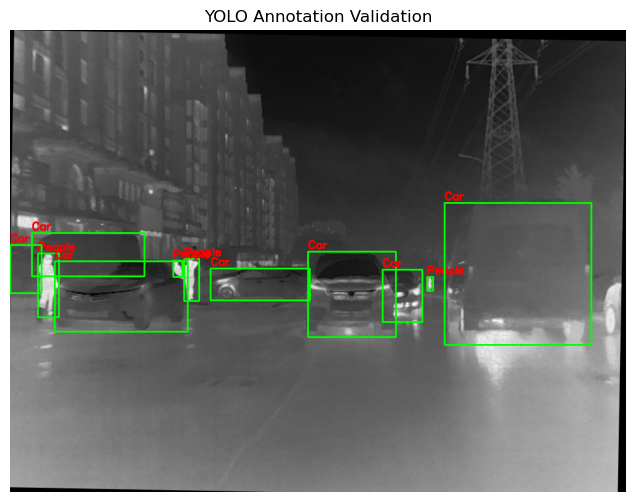

In [4]:
import cv2
import matplotlib.pyplot as plt

# Paths
IMAGE_PATH = "/media/nima/7CEEFEC0EEFE71AE/space/M3FD/Ir/00000.png"       # change to a real image
LABEL_PATH = "/media/nima/7CEEFEC0EEFE71AE/space/M3FD/Annotation/00000.txt"    # corresponding txt file

# Class mapping (EDIT THIS to match your dataset)
CLASS_MAPPING = {
    "People": 0,
    "Car": 1,
    "Bus": 2,
    "Motorcycle": 3,
    "Lamp": 4,
    "Truck": 5,
    # add more classes here
}

# Reverse class mapping for visualization
ID_TO_CLASS = {v: k for k, v in CLASS_MAPPING.items()}

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

# Read YOLO labels
with open(LABEL_PATH, "r") as f:
    lines = f.readlines()

for line in lines:
    class_id, x_c, y_c, bw, bh = map(float, line.split())

    # Convert back to pixel coordinates
    x_c *= w
    y_c *= h
    bw *= w
    bh *= h

    xmin = int(x_c - bw / 2)
    ymin = int(y_c - bh / 2)
    xmax = int(x_c + bw / 2)
    ymax = int(y_c + bh / 2)

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    label = ID_TO_CLASS[int(class_id)]
    cv2.putText(
        img, label, (xmin, ymin - 5),
        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2
    )

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO Annotation Validation")
plt.show()


# train / val split + copy

In [5]:
import os
import random
import shutil

# ===================== CONFIG =====================
DATA_ROOT = "/media/nima/7CEEFEC0EEFE71AE/space/M3FD"

IR_DIR = os.path.join(DATA_ROOT, "Ir")
VIS_DIR = os.path.join(DATA_ROOT, "Vis")
LBL_DIR = os.path.join(DATA_ROOT, "Annotation")

TRAIN_IR = os.path.join(DATA_ROOT, "train", "imgr")
TRAIN_VIS = os.path.join(DATA_ROOT, "train", "img")
TRAIN_LBL = os.path.join(DATA_ROOT, "train", "label")

VAL_IR = os.path.join(DATA_ROOT, "val", "imgr")
VAL_VIS = os.path.join(DATA_ROOT, "val", "img")
VAL_LBL = os.path.join(DATA_ROOT, "val", "label")

TOTAL_IMAGES = 4200
TRAIN_SIZE = 3360
VAL_SIZE = 840
RANDOM_SEED = 42
# ==================================================

# create output directories
for d in [TRAIN_IR, TRAIN_VIS, TRAIN_LBL, VAL_IR, VAL_VIS, VAL_LBL]:
    os.makedirs(d, exist_ok=True)

# generate indices 00000–04199
indices = list(range(TOTAL_IMAGES))

# reproducible random split
random.seed(RANDOM_SEED)
random.shuffle(indices)

train_ids = indices[:TRAIN_SIZE]
val_ids = indices[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

assert len(train_ids) == TRAIN_SIZE
assert len(val_ids) == VAL_SIZE

def copy_files(id_list, ir_dst, vis_dst, lbl_dst):
    for idx in id_list:
        name = f"{idx:05d}"

        ir_src = os.path.join(IR_DIR, f"{name}.png")
        vis_src = os.path.join(VIS_DIR, f"{name}.png")
        lbl_src = os.path.join(LBL_DIR, f"{name}.txt")

        shutil.copy2(ir_src, os.path.join(ir_dst, f"{name}.png"))
        shutil.copy2(vis_src, os.path.join(vis_dst, f"{name}.png"))
        shutil.copy2(lbl_src, os.path.join(lbl_dst, f"{name}.txt"))

# copy train set
copy_files(train_ids, TRAIN_IR, TRAIN_VIS, TRAIN_LBL)

# copy validation set
copy_files(val_ids, VAL_IR, VAL_VIS, VAL_LBL)

# save split lists (recommended for reproducibility)
with open(os.path.join(DATA_ROOT, "train.txt"), "w") as f:
    for i in train_ids:
        f.write(f"{i:05d}\n")

with open(os.path.join(DATA_ROOT, "val.txt"), "w") as f:
    for i in val_ids:
        f.write(f"{i:05d}\n")

print("✅ Split completed successfully")
print(f"Train images: {len(train_ids)}")
print(f"Val images: {len(val_ids)}")


6

6

6

6

6

...

6

6

6

6

✅ Split completed successfully
Train images: 3360
Val images: 840
